# **Task 3: Crop Yield Prediction (Agri AI)**

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 1. Data Loading
df = pd.read_csv('/content/EMG-data.csv')

if 'Yield' not in df.columns:
    possible_yield_cols = [col for col in df.columns if 'yield' in col.lower()]
    if possible_yield_cols:
        df = df.rename(columns={possible_yield_cols[0]: 'Yield'})
    else:
        df = df.rename(columns={df.columns[-1]: 'Yield'})

print('Initial DataFrame Head:')
print(df.head())
print('\nInitial DataFrame Info:')
df.info()
print('\nMissing values before handling:')
print(df.isnull().sum())

if 'channel2' in df.columns and df['channel2'].dtype == 'object':
    df['channel2'] = pd.to_numeric(df['channel2'], errors='coerce')

if 'channel7' in df.columns and df['channel7'].dtype == 'object':
    df['channel7'] = pd.to_numeric(df['channel7'], errors='coerce')

df.dropna(inplace=True)
print('\nMissing values after handling:')
print(df.isnull().sum())

print('\nCorrelation Matrix for Numerical Features:')
print(df.select_dtypes(include=np.number).corr()['Yield'].sort_values(ascending=False))

X = df.drop('Yield', axis=1)
y = df['Yield']

categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=np.number).columns

numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(random_state=42),
    'XGBoost Regressor': XGBRegressor(random_state=42, eval_metric='rmse')
}

results = {}
predictions = {}

for name, model in models.items():
    print(f'\nTraining {name}...')
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results[name] = {'R2 Score': r2, 'MAE': mae, 'RMSE': rmse}
    predictions[name] = y_pred

    print(f'{name} Evaluation:')
    print(f'  R2 Score: {r2:.4f}')
    print(f'  MAE: {mae:.4f}')
    print(f'  RMSE: {rmse:.4f}')

print('\nModel Performance Summary:')
print(pd.DataFrame(results).T)

best_model_name = max(results, key=lambda k: results[k]['R2 Score'])
print(f'\nDisplaying Predictions vs Actuals for {best_model_name}:')

final_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                 ('regressor', models[best_model_name])])
final_pipeline.fit(X_train, y_train)
final_predictions = final_pipeline.predict(X_test)

prediction_df = pd.DataFrame({'Actual Yield': y_test, 'Predicted Yield': final_predictions})
print(prediction_df.head(10))


print('\nFeature Importance (from Random Forest Regressor, for insights):')

preprocessor_fitted_for_rf = final_pipeline.named_steps['preprocessor']

all_features = preprocessor_fitted_for_rf.get_feature_names_out()

if 'Random Forest Regressor' in models and hasattr(final_pipeline.named_steps['regressor'], 'feature_importances_'):
    rf_importances = final_pipeline.named_steps['regressor'].feature_importances_
    feature_importance_df = pd.DataFrame({'Feature': all_features, 'Importance': rf_importances})
    print(feature_importance_df.sort_values(by='Importance', ascending=False).head(10))

print('\nCoefficients (from Linear Regression, for insights):')
if 'Linear Regression' in models:
    lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                  ('regressor', LinearRegression())])
    lr_pipeline.fit(X_train, y_train)
    lr_coefficients = lr_pipeline.named_steps['regressor'].coef_

    preprocessor_fitted_for_lr = lr_pipeline.named_steps['preprocessor']
    all_features_lr = preprocessor_fitted_for_lr.get_feature_names_out()

    coefficient_df = pd.DataFrame({'Feature': all_features_lr, 'Coefficient': lr_coefficients})
    print(coefficient_df.sort_values(by='Coefficient', ascending=False).head(10))

Initial DataFrame Head:
   time  channel1  channel2  channel3  channel4  channel5  channel6  channel7  \
0     1   0.00001  -0.00002  -0.00001  -0.00003   0.00000  -0.00001   0.00000   
1     5   0.00001  -0.00002  -0.00001  -0.00003   0.00000  -0.00001   0.00000   
2     6  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   
3     7  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   
4     8  -0.00001   0.00001   0.00002   0.00000   0.00001  -0.00002  -0.00001   

   channel8  class  Yield  
0  -0.00001    0.0    1.0  
1  -0.00001    0.0    1.0  
2   0.00001    0.0    1.0  
3   0.00001    0.0    1.0  
4   0.00001    0.0    1.0  

Initial DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891577 entries, 0 to 891576
Data columns (total 11 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   time      891577 non-null  int64  
 1   channel1  891577 non-null  float64
 2   channel2  891577 non

KeyboardInterrupt: 

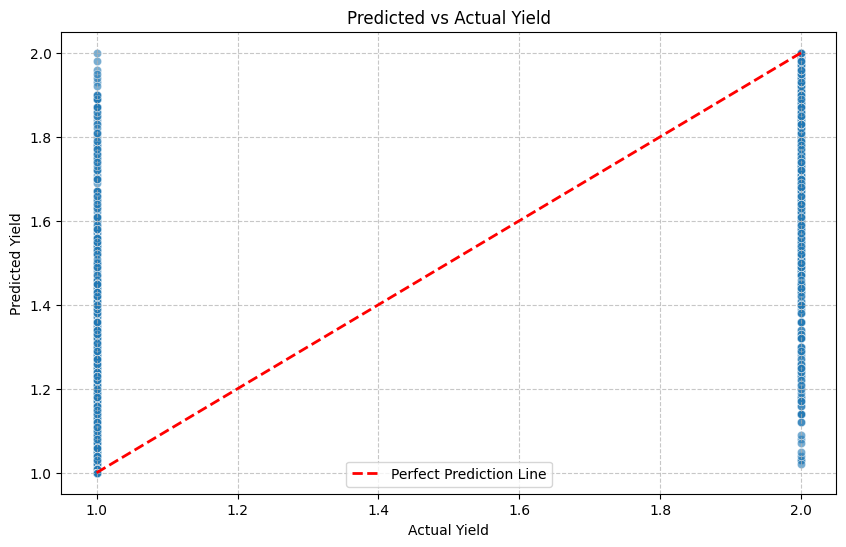

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Actual Yield', y='Predicted Yield', data=prediction_df, alpha=0.6)
plt.plot([prediction_df['Actual Yield'].min(), prediction_df['Actual Yield'].max()],
         [prediction_df['Actual Yield'].min(), prediction_df['Actual Yield'].max()],
         color='red', linestyle='--', lw=2, label='Perfect Prediction Line')
plt.title('Predicted vs Actual Yield')
plt.xlabel('Actual Yield')
plt.ylabel('Predicted Yield')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()